In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import random

In [2]:
fontsize=12
boxsize = 205
snapnum = 40

In [3]:
base_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all"
ihalo_dir = f"{base_dir}/mvir/ihalo"

#### Read data for central subhalos

In [4]:
tng_data1 = np.loadtxt(f"{ihalo_dir}/sfr-halomass_central.txt")

KeyboardInterrupt: 

In [ ]:
mask_min = tng_data1[:,1] > 10
ihalo_tng1 = tng_data1[:,0][mask_min]
mhalo_tng1 = tng_data1[:,1][mask_min]
pos_tng1 = tng_data1[:,2:5][mask_min]
sfr_tng1 = tng_data1[:,5][mask_min]

### Read data for central galaxies with 0 sfr

In [10]:
tng_data2 = np.loadtxt(f"{ihalo_dir}/sfr-cent_0sfr.txt")

In [11]:
mask_min2 = tng_data2[:,1] > 10
ihalo_tng2 = tng_data2[:,0][mask_min2]
mhalo_tng2 = tng_data2[:,1][mask_min2]
pos_tng2 = tng_data2[:,2:5][mask_min2]
sfr_tng2 = tng_data2[:,5][mask_min2]

### Read data for groups (if needed)

In [5]:
tng_data_sum = np.loadtxt(f"{ihalo_dir}/sfr-halomass_sum.txt")

In [6]:
mask_min_sum = tng_data_sum[:,1] > 10
ihalo_tng_sum = tng_data_sum[:,0][mask_min_sum]
mhalo_tng_sum = tng_data_sum[:,1][mask_min_sum]
pos_tng_sum = tng_data_sum[:,2:5][mask_min_sum]
sfr_tng_sum = tng_data_sum[:,5][mask_min_sum]

Read data for groups with 0 sfr

In [7]:
tng_data_sum0 = np.loadtxt(f"{ihalo_dir}/sfr-sum_0sfr_logM10.txt")

In [8]:
mask_min_sum0 = tng_data_sum0[:,1] > 10
ihalo_tng_sum0 = tng_data_sum0[:,0][mask_min_sum0]
mhalo_tng_sum0 = tng_data_sum0[:,1][mask_min_sum0]
pos_tng_sum0 = tng_data_sum0[:,2:5][mask_min_sum0]
sfr_tng_sum0 = tng_data_sum0[:,5][mask_min_sum0]

In [9]:
ihalo_tng3 = np.concatenate((ihalo_tng_sum, ihalo_tng_sum0))
mhalo_tng3 = np.concatenate((mhalo_tng_sum, mhalo_tng_sum0))
pos_tng3 = np.concatenate((pos_tng_sum, pos_tng_sum0))
sfr_tng3 = np.concatenate((sfr_tng_sum, sfr_tng_sum0))

Concatenate arrays of central galaxies with zero and nonzero SFR

In [12]:
ihalo_tng3 = np.concatenate((ihalo_tng1,ihalo_tng2))
mhalo_tng3 = np.concatenate((mhalo_tng1,mhalo_tng2))
pos_tng3 = np.concatenate((pos_tng1,pos_tng2))
sfr_tng3 = np.concatenate((sfr_tng1,sfr_tng2))

In [255]:
mask = False
if mask is True:
    mask_min3 = (mhalo_tng3 > 10) & (pos_tng3[:,2] < 30) 
else:
    mask_min3 = mhalo_tng3 > 0

Function for computing standard deviation for the data above the median

In [9]:
def upper_std(data):
    median = np.median(data)
    if (median > -5) & (median is not None):
        mask_upper = data > median
        diff = data[mask_upper] - median
        new_below_data = median - diff
        new_data = np.concatenate((data[mask_upper], new_below_data))
        std = np.std(new_data)
    else:
        std = np.nan
    return std

In [10]:
def lower_std(data):
    median = np.median(data)
    if (median > -5) & (median is not None):
        mask_lower = data < median
        diff = median - data[mask_lower]
        new_above_data = median + diff
        new_data = np.concatenate((data[mask_lower], new_above_data))
        std = np.std(new_data)
    else:
        std = np.nan
    return std

In [20]:
dp = 1
dlogM = 1/10**dp
print(dlogM)
mhalo_bins = np.round(np.arange(10, 15, dlogM),dp)
print(len(mhalo_bins))

0.1
50


Put in bins of width 0.1 dex

In [21]:
#mhalo_bins = np.unique(mhalo_tng[mask_min3]) # return sorted unique values
def bin_data(ihalo_tng3, mhalo_tng3, pos_tng3, sfr_tng3):
    mask_min3 = mhalo_tng3 > 0


    ihalo_binned = []
    mhalo_binned = []
    sfr_binned = []
    pos_binned = []
    sfr_medians = []
    sfr_log_means = []
    sfr_linear_means = []
    sfr_stds = []
    sfr_upper_stds = []
    sfr_lower_stds = []
    hods = []
    sfr75s = []
    sfr25s = []
    count1 = 0
    print("logM Nhalo Median STD upper_STD")

    mask_high = mhalo_tng3[mask_min3] > 15

    median_high = np.median(sfr_tng3[mask_min3][mask_high])
    std_high = np.std(sfr_tng3[mask_min3][mask_high])
    sfr_upper_std_high = upper_std(sfr_tng3[mask_min3][mask_high])
    sfr_lower_std_high = lower_std(sfr_tng3[mask_min3][mask_high])
    
    if np.sum(mask_high) > 5:
        sfr_75_high = np.percentile(sfr_tng3[mask_min3][mask_high], 75)
        sfr_25_high = np.percentile(sfr_tng3[mask_min3][mask_high], 25)
    else:
        sfr_75_high = np.nan
        sfr_25_high = np.nan

    for mhalo_val in mhalo_bins:
        mask_bin = np.round(mhalo_tng3[mask_min3], dp) == np.round(mhalo_val, dp) 

        if mhalo_val > 15:
            median = median_high
            std = std_high
            sfr_upper_std = sfr_upper_std_high
            sfr_lower_std = sfr_lower_std_high
            sfr_75 = sfr_75_high
            sfr_25 = sfr_25_high
        else:
            median = np.median(sfr_tng3[mask_min3][mask_bin])
            log_mean = np.mean(sfr_tng3[mask_min3][mask_bin])
            linear_mean = np.log10(np.mean(10**sfr_tng3[mask_min3][mask_bin]))
            std = np.std(sfr_tng3[mask_min3][mask_bin])
            sfr_upper_std = upper_std(sfr_tng3[mask_min3][mask_bin])
            sfr_lower_std = lower_std(sfr_tng3[mask_min3][mask_bin])
            if np.sum(mask_bin) > 5:
                sfr_75 = np.percentile(sfr_tng3[mask_min3][mask_bin], 75)
                sfr_25 = np.percentile(sfr_tng3[mask_min3][mask_bin], 25)
            else:
                sfr_75 = np.nan
                sfr_25 = np.nan
        


        ihalo_binned.append(ihalo_tng3[mask_min3][mask_bin]) 
        count1 += len(ihalo_tng3[mask_min3][mask_bin])
        mhalo_binned.append(mhalo_tng3[mask_min3][mask_bin])
        sfr_binned.append(sfr_tng3[mask_min3][mask_bin])
        pos_binned.append(pos_tng3[mask_min3][mask_bin])
        
        mask_nonzero = sfr_tng3[mask_min3][mask_bin] > -5
        Nnonzero = np.sum(mask_nonzero)
        Nzero = np.sum(~mask_nonzero)
        Ntot = Nzero + Nnonzero
        
        hods.append(Nnonzero/Ntot)

        sfr_medians.append(median)
        sfr_log_means.append(log_mean)
        sfr_linear_means.append(linear_mean)
        sfr_stds.append(std)
        sfr_upper_stds.append(sfr_upper_std)
        sfr_lower_stds.append(sfr_lower_std)
        sfr75s.append(sfr_75)
        sfr25s.append(sfr_25)
        #if np.sum(mask_bin) < 10:
        #    print(mhalo_val, np.sum(mask_bin), median, std, sfr_upper_std)
        
    binned_dict ={
    "ihalo": ihalo_binned,
     "mhalo": mhalo_binned,
     "sfr": sfr_binned,
     "pos": pos_binned,
     "sfr_median": sfr_medians,
    "sfr_log_mean": sfr_log_means,
    "sfr_linear_mean": sfr_linear_means,
     "sfr_std": sfr_stds,
     "sfr_upper_std": sfr_upper_stds,
    "sfr_lower_std": sfr_lower_stds,
     "hod": hods,
     "sfr75": sfr75s,
     "sfr25": sfr25s,
    "mhalo_bins": mhalo_bins}
     
     
    return binned_dict





In [13]:
binned_all =  bin_data(ihalo_tng3, mhalo_tng3, pos_tng3, sfr_tng3)

0.1
50
logM Nhalo Median STD upper_STD


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:202: RuntimeWarning: invalid value encountered in subtract
  x = a

In [14]:
binned_nonzero = bin_data(ihalo_tng_sum, mhalo_tng_sum, pos_tng_sum, sfr_tng_sum)

0.1
50
logM Nhalo Median STD upper_STD


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:78: RuntimeWarning: invalid value encountered in long_scalars


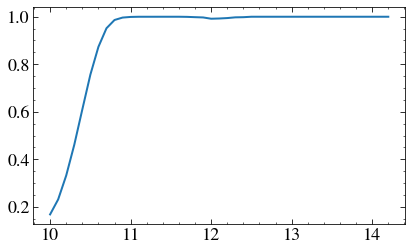

In [296]:
plt.plot(mhalo_bins, binned_all["hod"])

Text(0.5, 0, 'log$_{10}$M$_{\\rm halo}$ [M$_\\odot$h$^{-1}$]')

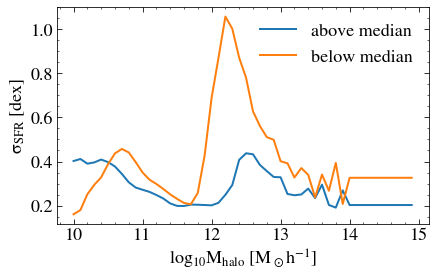

In [360]:
binned_data = binned_nonzero
plt.plot(mhalo_bins, binned_data["sfr_upper_std"], label="above median")
plt.plot(mhalo_bins, binned_data["sfr_lower_std"], label="below median")
plt.legend(loc="upper right")
plt.ylabel(r"$\rm \sigma_{SFR}$ [dex]")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")

In [285]:
def plot_std(binned_data):
    std_all_up = np.array(binned_data["sfr_median"]) + np.array(binned_data["sfr_upper_std"])
    std_all_down = np.array(binned_data["sfr_median"]) - np.array(binned_data["sfr_upper_std"])
    plt.fill_between(mhalo_bins, std_all_up, std_all_down, alpha = 0.5)

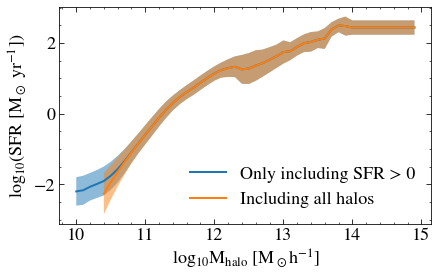

In [288]:

plot_std(binned_nonzero)
plt.plot(mhalo_bins, binned_nonzero["sfr_median"], label="Only including SFR > 0")
plot_std(binned_all)
plt.plot(mhalo_bins, binned_all["sfr_median"], label="Including all halos")



#plt.fill_between(mhalo_bins, std_all_up, std_all_down, alpha = 0.5)
plt.legend()
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.show()
plt.clf()
plt.close()

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


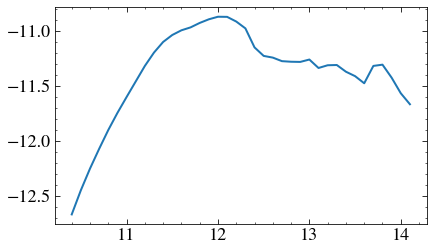

In [553]:
plt.plot(mhalo_bins[:-8], np.log10(10**np.array(binned_all["sfr_median"][:-8])/10**mhalo_bins[:-8]), label="Including all halos")


In [522]:
a1 = 1.8
b1 = -20.5
y = a1*12 + b1
print(y)
a2 = 0.7
b2 = y - a2*12
print(b2)
b2 = -7.3
print(b2)
y = a2*12 + b2
print(y)

1.1000000000000014
-7.299999999999997
-7.3
1.0999999999999988


In [655]:
def mean_relation(logM):
    M = 10**logM
    M1 = 10**11.5
    a = -11
    b = 1.7
    c = 0.35
   
    sfr = np.log10(2*10**a/((M/M1)**-b + (M/M1)**c))
    return sfr

In [656]:
logMs = np.arange(10,14.3, 0.1)
sfrs1 = mean_relation(logMs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


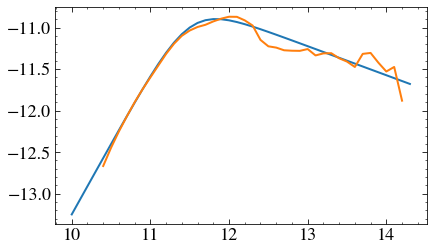

In [658]:
plt.plot(logMs, sfrs1)
plt.plot(mhalo_bins, np.log10(10**np.array(binned_all["sfr_median"])/10**mhalo_bins), label="Including all halos")


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


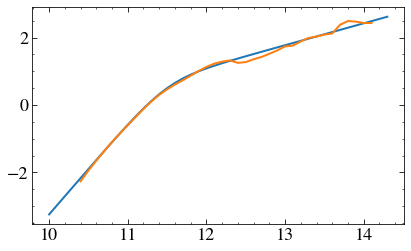

In [10]:
plt.scatter(mhalos, tng_sfrs, s=0.1,  color="lightgrey")
plt.plot(logMs, np.log10(10**logMs * 10**sfrs1), label="Toy model", color=palette_tab10[2], linewidth=3)
plt.plot(mhalo_bins, np.log10(10**np.array(binned_all["sfr_median"])),  linestyle="dashed", label="TNG median", color=palette_tab10[1], linewidth=3)


plt.legend(loc="lower right")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures2/invented_smooth_vs_tng.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

NameError: name 'mhalos' is not defined

In [501]:
b1=1.1-(12*0.7)
print(b1)

-7.299999999999999


In [503]:
poly_low = np.poly1d((a1,b1))
poly_high = np.poly1d((a2,b2))

In [511]:
x1 = np.arange(10,12.1, 0.5)
y1 = poly_low(x1)
x2 = np.arange(12,15, 0.5)
y2 = poly_high(x2)

In [499]:
print(mhalo_bins[20:25])
print(sfr_medians[20:25])

[12.  12.1 12.2 12.3 12.4]
[1.1330524304132377, 1.2309431304458385, 1.2887281361741025, 1.3254016852141697, 1.2518211484372044]


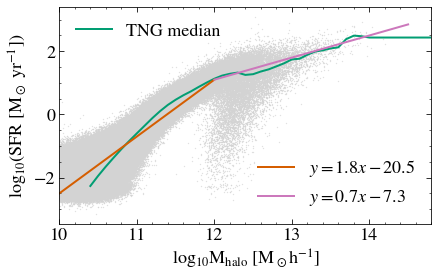

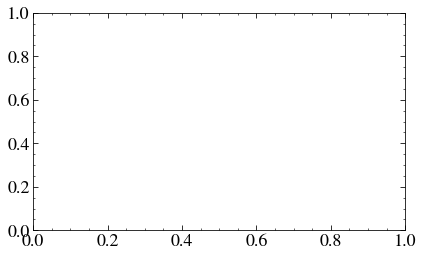

In [523]:
plt.scatter(mhalos, tng_sfrs, s=0.1,  color="lightgrey")

plt.plot(mhalo_bins, binned_all["sfr_median"], label="TNG median", c=palette_tab10[2])
legend1 = plt.legend(loc='upper left')
plt.gca().add_artist(legend1)
plt.plot(x1, y1, label=r"$ y = 1.8x - 20.5$", c=palette_tab10[3])
plt.plot(x2, y2, label="$y = 0.7x - 7.3$", c=palette_tab10[4])

handles2, labels2 = plt.gca().get_legend_handles_labels()
plt.legend(handles2[1:], labels2[1:], loc="lower right")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.xlim(10,14.8)
#plt.savefig("../figures2/invented_vs_tng.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.cla()

Text(0.5, 0, 'log$_{10}$M$_{\\rm halo}$ [M$_\\odot$h$^{-1}$]')

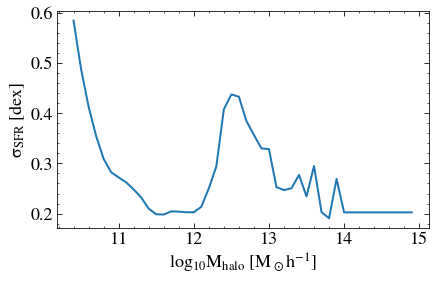

In [248]:
plt.plot(mhalo_bins, sfr_upper_stds)
plt.ylabel(r"$\rm \sigma_{SFR}$ [dex]")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")

Text(0.5, 0, 'log$_{10}$M$_{\\rm halo}$ [M$_\\odot$h$^{-1}$]')

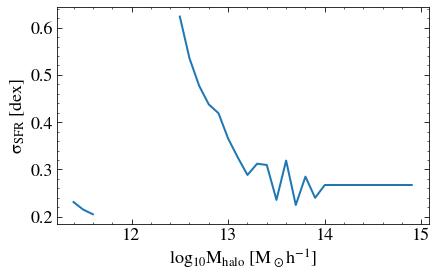

In [249]:
plt.plot(mhalo_bins, sfr_stds)
plt.ylabel(r"$\rm \sigma_{SFR}$ [dex]")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")

In [506]:
mhalos = np.concatenate(mhalo_binned)
pos = np.concatenate(pos_binned)
tng_sfrs = np.concatenate(sfr_binned)

Assign SFRs using median as mean and upper_std as standard deviation

In [12]:
seed = 0

logM = 16

stds = binned_nonzero["sfr_upper_std"]
sfr_medians = binned_nonzero["sfr_median"]
sfr_means = binned_nonzero["sfr_linear_mean"]
sfr_binned = binned_nonzero["sfr"]
mhalo_binned = binned_nonzero["mhalo"]
pos_binned = binned_nonzero["pos"]
hods = binned_nonzero["hod"]
mhalo_bins = binned_nonzero["mhalo_bins"]

mhalos = np.concatenate(mhalo_binned)
pos = np.concatenate(pos_binned)
tng_sfrs = np.concatenate(sfr_binned)
sigma = 0.2
#odir = f"/cosma8/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_median_std/upper_std"
odir = f"/cosma8/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_linear_mean/changed_sfr_func/nonzero/sigma={sigma}_interped"

is_mean = True
#use_hod = False
#odir1 = f"/cosma7/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_median/nonzero/sigma={sigma}"

is_tng_sfrs = False
is_print = False

if is_print:
    if not os.path.exists(odir):
        os.makedirs(odir)

sfr_renormed_list = []
for seed in range(0,5):
    new_sfrs = []
    
    np.random.seed(seed)
    #f_group = open(f"{odir}/logM<{logM}/seed{seed}.txt", "w")

    for ibin in range(len(mhalo_binned)):
        #sigma = stds[ibin]
        
        for ihalo in range(len(mhalo_binned[ibin])):
            
            if mhalo_binned[ibin][ihalo] < logM:
                rand = np.random.rand()
                if rand < hods[ibin]:
                    if is_mean:
                        
                        if sigma == 0:
                            sfr = np.interp(mhalo_binned[ibin][ihalo],mhalo_bins, sfr_means)
                        else:
                            sfr = np.random.normal(sfr_means[ibin], sigma)
                            
                    else:
                        sfr = np.random.normal(sfr_medians[ibin], sigma)
                else:
                    sfr = -5
                
                #sfr = sfr_medians[ibin]
                
            else:
                sfr = sfr_binned[ibin][ihalo]                   
            new_sfrs.append(sfr)
            #print(mhalo_binned[ibin][ihalo], pos_binned[ibin][ihalo][0], pos_binned[ibin][ihalo][1], pos_binned[ibin][ihalo][2], sfr, file=f_group)
    
    #f_group.close()
    sorted_new_sfr_indices = np.flip(np.argsort(new_sfrs)) 
    
    mhalos_renormed = mhalos[sorted_new_sfr_indices]
    pos_renormed = pos[sorted_new_sfr_indices]
    if is_tng_sfrs:
        sfrs_renormed = np.flip(np.sort(tng_sfrs))
    else:
        sfrs_renormed = np.array(new_sfrs)[sorted_new_sfr_indices]
    
    #odir = "/cosma8/data/dp004/dc-zhan5/assignment_schemes/gaussian/tng_median_std/upper_std"
    
    sfrs_renormed_list.append(sfrs_renormed)
    
    if is_print:
        f_renormed = open(f"{odir}/seed{seed}.txt", "w")
        for ihalo in range(len(mhalos_renormed)):
            print(mhalos_renormed[ihalo], pos_renormed[ihalo][0], pos_renormed[ihalo][1], pos_renormed[ihalo][2], sfrs_renormed[ihalo], file=f_renormed)
        f_renormed.close()

    



NameError: name 'binned_nonzero' is not defined

(array([5.17748e+05, 1.85560e+05, 1.32463e+05, 8.89050e+04, 5.98920e+04,
        5.51340e+04, 3.46760e+04, 1.74980e+04, 1.35000e+03, 7.80000e+01]),
 array([-1.98515713, -1.52408078, -1.06300443, -0.60192808, -0.14085173,
         0.32022462,  0.78130097,  1.24237732,  1.70345367,  2.16453002,
         2.62560637]),
 <BarContainer object of 10 artists>)

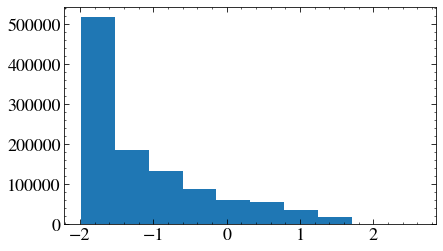

In [707]:
plt.hist(sfrs_renormed)

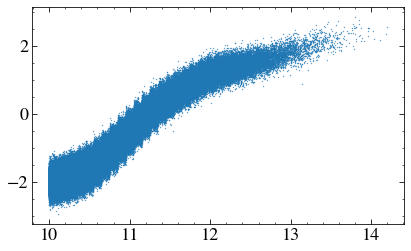

In [710]:
plt.scatter(mhalos_renormed, sfrs_renormed, s=0.1)
plt.show()
plt.clf()
plt.close()

In [23]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

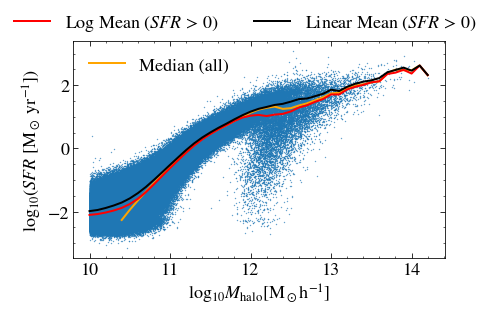

In [45]:

plt.scatter(mhalo_tng3, sfr_tng3, s=0.1)

median = plt.plot(mhalo_bins, binned_all["sfr_median"], c="orange", label="Median (all)")
log_mean = plt.plot(mhalo_bins, binned_nonzero["sfr_log_mean"], c="red", label="Log Mean ($SFR$ > 0)")
lin_mean = plt.plot(mhalo_bins, binned_nonzero["sfr_linear_mean"], c="black", label="Linear Mean ($SFR$ > 0)")

#plt.plot(np.sort(mhalo_tng1), np.sort(sfr_tng1), label="HAM", c="red")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.xlabel(r"$\rm log_{10} $$M_{\mathrm{halo}}$$\rm[M_\odot h^{-1}$]")
plt.ylabel('log$_{10}$($SFR$ [M$_\odot$ yr$^{-1}$])')
ax =plt.gca()
h, l = ax.get_legend_handles_labels()
leg1 = plt.legend(handles = h[:1], loc="upper left", bbox_to_anchor=(0,1))
ax.add_artist(leg1)
plt.legend(handles = h[1:], loc="upper left", ncol=2, bbox_to_anchor=(-0.2,1.2))
                             
#plt.savefig("../figures2/tng_median_means.png", format="png", bbox_inches="tight", dpi=300)                                
plt.show()
plt.clf()
plt.close()

In [109]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [507]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8352941176470589, 0.3686274509803922, 0.0), (0.8, 0.47058823529411764, 0.7372549019607844), (0.792156862745098, 0.5686274509803921, 0.3803921568627451), (0.984313725490196, 0.6862745098039216, 0.8941176470588236), (0.5803921568627451, 0.5803921568627451, 0.5803921568627451), (0.9254901960784314, 0.8823529411764706, 0.2), (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]


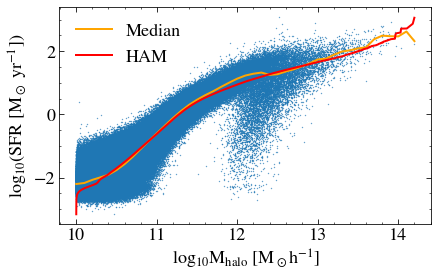

In [416]:

plt.scatter(mhalo_tng3, sfr_tng3, s=0.1)
plt.plot(mhalo_bins, binned_nonzero["sfr_median"], c="orange", label="Median")
plt.plot(np.sort(mhalo_tng1), np.sort(sfr_tng1), label="HAM", c="red")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend()
plt.show()
plt.clf()
plt.close()

In [408]:
binned_renormed = bin_data(ihalo_tng3, mhalos_renormed, pos_renormed, sfrs_renormed)

0.1
50
logM Nhalo Median STD upper_STD


/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:202: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/function_base.py:3968: RuntimeWarning: invalid value encountered in multiply
  x2 = take(ap, indices_above, axis=axis) * weights_above
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:74: RuntimeWarning: invalid value encountered in long_scalars


No handles with labels found to put in legend.


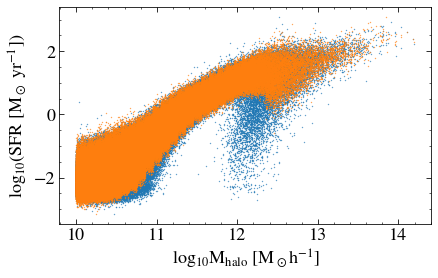

In [409]:
plt.scatter(mhalo_tng3, sfr_tng3, s=0.1)
plt.scatter(mhalos_renormed, sfrs_renormed, s=0.1)

#plt.errorbar(mhalo_bins, sfr_medians, yerr=[sfr_upper_stds, sfr_upper_stds], c="orange", label="Median")
#plt.xlim(10,14)
#plt.ylim(-3,3)
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.legend(loc="upper left")
plt.show()
plt.clf()
plt.close()

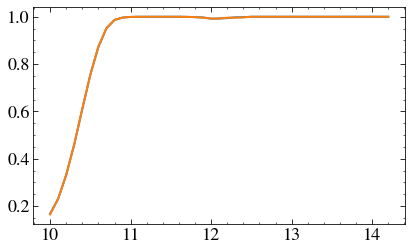

In [388]:
plt.plot(mhalo_bins, binned_all["hod"])
plt.plot(mhalo_bins, binned_renormed["hod"])

In [ ]:
def plot_percentiles(binned_data):
    std_all_up = np.array(binned_data["sfr25"]) + np.array(binned_data["sfr_upper_std"])
    std_all_down = np.array(binned_data["sfr_median"]) - np.array(binned_data["sfr_upper_std"])
    plt.fill_between(mhalo_bins, std_all_up, std_all_down, alpha = 0.5)

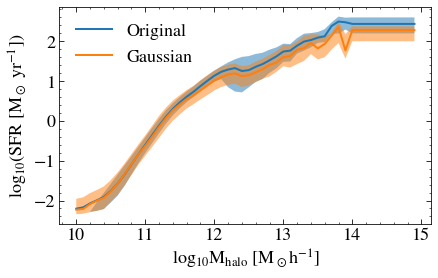

In [370]:


plt.plot(mhalo_bins, binned_nonzero["sfr_median"], label="Original")
plt.fill_between(mhalo_bins, binned_nonzero["sfr25"], binned_all["sfr75"], alpha = 0.5)
plt.plot(mhalo_bins, binned_renormed["sfr_median"], label="Gaussian")
plt.fill_between(mhalo_bins, binned_renormed["sfr25"], binned_renormed["sfr75"], alpha = 0.5)



#plt.fill_between(mhalo_bins, std_all_up, std_all_down, alpha = 0.5)
plt.legend()
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.show()
plt.clf()
plt.close()

In [130]:
def luminosity_function(sfrs, boxsize=205, log_sfr_min=-3.5, log_sfr_max=3.5, delta_log_sfr=0.1,
                       calculate_err=True):
    nbins = int(1 + (log_sfr_max - log_sfr_min)/delta_log_sfr)
    bins = np.linspace(log_sfr_min, log_sfr_max, num=nbins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    num_halos = np.histogram(sfrs, bins)[0]

    normalisation = (boxsize**3) * delta_log_sfr

    if calculate_err:
        # Calculate error bars assuming Poisson distribution in each bin
        errs = np.sqrt(num_halos)/normalisation

    bin_counts = num_halos / normalisation
    
    return bin_centers, bin_counts, errs

    

In [711]:
bin_centers, bin_counts, errs = luminosity_function(sfr_tng3)

In [712]:
bin_centers1, bin_counts1, errs1 = luminosity_function(sfrs_renormed)

In [723]:
bin_centers2, bin_counts2, errs2 = luminosity_function(sfrs_renormed)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in subtract
  """Entry point for launching an IPython kernel.
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in subtract
  
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in log10
  """
/cosma/local/Pyt

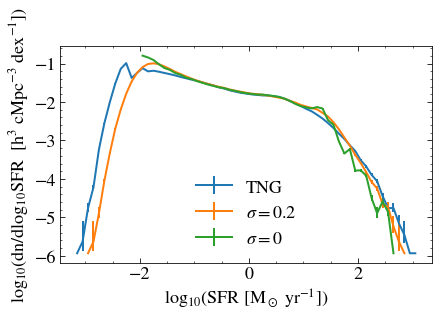

In [724]:
up_err = np.log10(bin_counts + errs) - np.log10(bin_counts)
down_err = np.log10(bin_counts) - np.log10(bin_counts - errs)
plt.errorbar(bin_centers, np.log10(bin_counts), yerr=[up_err, down_err], label="TNG")

up_err = np.log10(bin_counts1 + errs1) - np.log10(bin_counts1)
down_err = np.log10(bin_counts1) - np.log10(bin_counts1 - errs1)
plt.errorbar(bin_centers1, np.log10(bin_counts1), yerr=[up_err, down_err], label=r"$\sigma = 0.2$")

up_err = np.log10(bin_counts2 + errs2) - np.log10(bin_counts2)
down_err = np.log10(bin_counts2) - np.log10(bin_counts2 - errs2)
plt.errorbar(bin_centers2, np.log10(bin_counts2), yerr=[up_err, down_err], label=r"$\sigma = 0$")


plt.xlabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylabel(r"log$_{10}$(dn/dlog$_{10}$SFR  [h$^3$ cMpc$^{−3}$ dex$^{-1}$])")
plt.legend()
plt.show()
plt.clf()
plt.close()